In [ ]:
import numpy as np
from sklearn.metrics import r2_score, accuracy_score
from utils.data_handling import sequential_split, load_data
from utils.feature_creation import create_features
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [11]:
path = "../data/BRK.csv"
df = load_data(path)


In [12]:
features = create_features(df, classifier=False)
features = features.dropna()

X = features.drop(columns=['Close', 'Date'])
y = features['Close']

In [13]:
lin_model = LinearRegression()
rfmodel = RandomForestRegressor(n_estimators=1000, max_depth=10, random_state=42)
knn_model = KNeighborsRegressor(n_neighbors = 5)

In [14]:
fold_length = np.floor(len(X)/10).astype(int)   #Assigns 220 to fold_length (roughly 10% of dataset)
training_length = (np.floor(len(X)/10)*5).astype(int)  #Assigns 1100 to training_length (roughly 50% of dataset)

lin_acc_list = []   #Empty list to store directional accuracies of linear model
rf_acc_list = []    #Empty list to store directional accuracies of random forest model
knn_acc_list = []   #Empty list to store directional accuracies of knn model

In [15]:
'''Perform a rolling window cross validation where initial 50% of data is used for training and 
   the next 10% is used for testing. On iteration 2, data range from 10%-60% is used for training
   and range from 60% - 70% is used for testing, and so on.. '''
i = 0
for j in range(1, 6):
    training_subset_X = X[(i*fold_length):training_length+(i*fold_length)]
    training_subset_y = y[(i*fold_length):training_length+(i*fold_length)]
    testing_subset_X = X[training_length+(fold_length*i):training_length+(fold_length*j)]
    testing_subset_y = y[training_length+(fold_length*i):training_length+(fold_length*j)]

    '''Fitting and testing 5 different data subsets for the linear model'''
    lin_model.fit(training_subset_X, training_subset_y)
    validation_set_predictions = lin_model.predict(testing_subset_X)
    predicted_direction = (np.diff(validation_set_predictions) > 0).astype(int)
    actual_direction = (np.diff(testing_subset_y) > 0).astype(int)
    dir_acc = accuracy_score(actual_direction, predicted_direction) * 100
    #print(dir_acc)
    lin_acc_list.append(dir_acc)

    '''Fitting and testing 5 different data subsets for the random forest model'''
    rfmodel.fit(training_subset_X, training_subset_y)
    validation_set_predictions = rfmodel.predict(testing_subset_X)
    predicted_direction = (np.diff(validation_set_predictions) > 0).astype(int)
    actual_direction = (np.diff(testing_subset_y) > 0).astype(int)
    dir_acc = accuracy_score(actual_direction, predicted_direction) * 100
    #print(dir_acc)
    rf_acc_list.append(dir_acc)

    '''Fitting and testing 5 different data subsets for the knn model'''
    knn_model.fit(training_subset_X, training_subset_y)
    validation_set_predictions = knn_model.predict(testing_subset_X)
    predicted_direction = (np.diff(validation_set_predictions) > 0).astype(int)
    actual_direction = (np.diff(testing_subset_y) > 0).astype(int)
    dir_acc = accuracy_score(actual_direction, predicted_direction) * 100
    #print(dir_acc)
    knn_acc_list.append(dir_acc)

    i+=1

In [ ]:

#Calculate and print all mean directional accuracies
print(f'Linear Model Mean Directional Accuracy: {round(np.mean(lin_acc_list), 3)}%')
print(f'Random Forest Model Mean Directional Accuracy: {round(np.mean(rf_acc_list), 3)}%')
print(f'KNN Model Mean Directional Accuracy: {round(np.mean(knn_acc_list), 3)}%')



Linear Model Mean Directional Accuracy: 72.968%
Random Forest Model Mean Directional Accuracy: 70.32%
KNN Model Mean Directional Accuracy: 62.192%


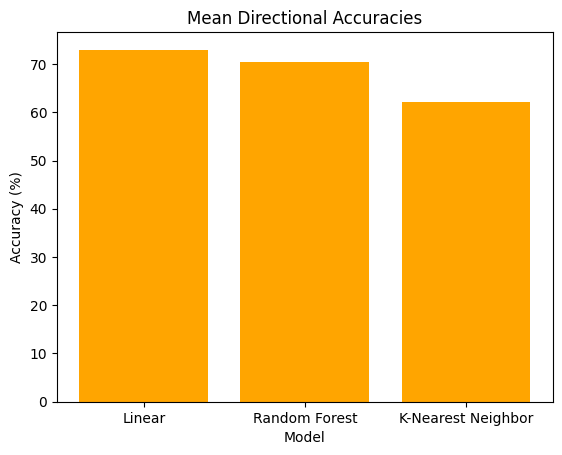

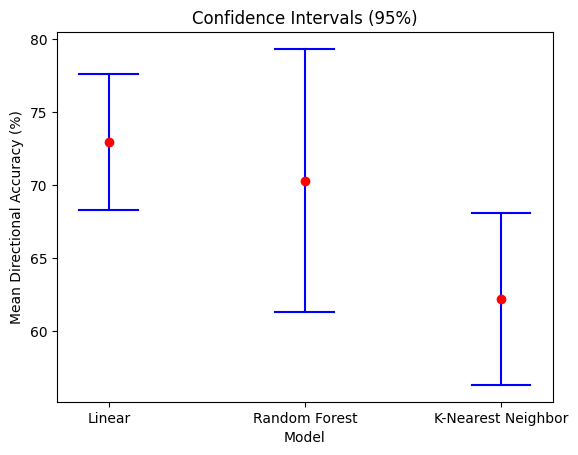

In [57]:
import matplotlib.pyplot as plt

'''Simple bar graph to display the mean directional accuracy'''
def plot_bar(x, mean_accuracy):
    plt.bar(x, mean_accuracy, color = 'orange')

'''Calculate 95% confidence interval using z score of 1.96 and format graph to display values
   for visual comparison of model performance '''
def plot_ci(x, accuracies, z = 1.96, color='blue', horizontal_line_width = 0.3):
    mean = np.mean(accuracies)
    st_dev = np.std(accuracies)
    confidence_interval = z * st_dev / np.sqrt(len(accuracies))

    left_margin = x - horizontal_line_width / 2
    right_margin = x + horizontal_line_width / 2
    upper_bound = mean + confidence_interval
    lower_bound = mean - confidence_interval
    plt.plot([x, x], [upper_bound, lower_bound], color=color)
    plt.plot([left_margin, right_margin], [upper_bound, upper_bound], color=color)
    plt.plot([left_margin, right_margin], [lower_bound, lower_bound], color=color)
    plt.plot(x, mean, 'o', color='red')

#Create and Display Bar Graph of Mean Directional Accuracies
plt.title('Mean Directional Accuracies')
plot_bar('Linear', np.mean(lin_acc_list))
plot_bar('Random Forest', np.mean(rf_acc_list))
plot_bar('K-Nearest Neighbor', np.mean(knn_acc_list))
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.show()

#Create and Display Graph of Confidence Intervals
plt.xticks([1, 2, 3], ['Linear', 'Random Forest', 'K-Nearest Neighbor'])
plt.title('Confidence Intervals (95%)')
plot_ci(1, lin_acc_list)
plot_ci(2, rf_acc_list)
plot_ci(3, knn_acc_list)
plt.xlabel('Model')
plt.ylabel('Mean Directional Accuracy (%)')
plt.show()

